## Notebook 06 — Model Training & Evaluation

#### استرجاع البيانات

In [1]:
import pandas as pd

# Original datasets

train_df = pd.read_parquet(
    "artifacts/train.parquet"
)

validation_df = pd.read_parquet(
    "artifacts/validation.parquet"
)

test_df = pd.read_parquet(
    "artifacts/test.parquet"
)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(67533, 23)
(14471, 23)
(14472, 23)


#### تحقق من وجود Target

In [2]:
"is_delayed" in train_df.columns

True

===============

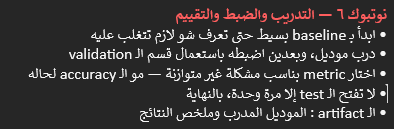

#### Imports

In [4]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

#### Load Features

In [5]:
X_train = pd.read_parquet(
    "artifacts/train_features.parquet"
)

X_validation = pd.read_parquet(
    "artifacts/validation_features.parquet"
)

X_test = pd.read_parquet(
    "artifacts/test_features.parquet"
)

print(X_train.shape)
print(X_validation.shape)
print(X_test.shape)

(67533, 42)
(14471, 42)
(14472, 42)


#### Load Targets

In [6]:
y_train = pd.read_parquet(
    "artifacts/y_train.parquet"
)

y_validation = pd.read_parquet(
    "artifacts/y_validation.parquet"
)

y_test = pd.read_parquet(
    "artifacts/y_test.parquet"
)

In [7]:
print(y_train.shape)
print(y_validation.shape)
print(y_test.shape)

(67533, 1)
(14471, 1)
(14472, 1)


#### تحويل Targets إلى Series

In [8]:
y_train = y_train.squeeze()

y_validation = y_validation.squeeze()

y_test = y_test.squeeze()

In [19]:
# تحقق

print(y_train.shape)
print(y_validation.shape)
print(y_test.shape)

(67533,)
(14471,)
(14472,)


###  Baseline Model (Dummy Classifier)
الهدف
* السؤال:
- هل الموديلات الحقيقية أفضل من التخمين؟


In [17]:
dummy_model = DummyClassifier(
strategy="most_frequent"
)

dummy_model.fit(
X_train,
y_train
)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [18]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.core.series.Series'>
(67533,)


In [20]:
#Prediction
dummy_pred = dummy_model.predict(
X_validation
)

In [21]:
# Evaluate
dummy_precision = precision_score(
y_validation,
dummy_pred,
zero_division=0
)

dummy_recall = recall_score(
y_validation,
dummy_pred,
zero_division=0
)

dummy_f1 = f1_score(
y_validation,
dummy_pred,
zero_division=0
)

print("Precision:", dummy_precision)
print("Recall:", dummy_recall)
print("F1:", dummy_f1)


Precision: 0.0
Recall: 0.0
F1: 0.0


### Logistic Regression

In [23]:
log_model = LogisticRegression(
max_iter=1000,
random_state=42
)

log_model.fit(
X_train,
y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [24]:
# Prediction
log_pred = log_model.predict(
X_validation
)

log_prob = log_model.predict_proba(
X_validation
)[:,1]


In [25]:
# Metrics
log_precision = precision_score(
y_validation,
log_pred
)

log_recall = recall_score(
y_validation,
log_pred
)

log_f1 = f1_score(
y_validation,
log_pred
)

log_auc = roc_auc_score(
y_validation,
log_prob
)

print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)
print("ROC AUC:", log_auc)


Precision: 0.42517006802721086
Recall: 0.16170763260025872
F1: 0.23430178069353327
ROC AUC: 0.764921253648043


#### Random Forest

In [26]:
rf_model = RandomForestClassifier(
n_estimators=100,
random_state=42,
n_jobs=-1
)

rf_model.fit(
X_train,
y_train
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
# Prediction
rf_pred = rf_model.predict(
X_validation
)

rf_prob = rf_model.predict_proba(
X_validation
)[:,1]


In [28]:
# Metrics
rf_precision = precision_score(
y_validation,
rf_pred
)

rf_recall = recall_score(
y_validation,
rf_pred
)

rf_f1 = f1_score(
y_validation,
rf_pred
)

rf_auc = roc_auc_score(
y_validation,
rf_prob
)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC AUC:", rf_auc)


Precision: 0.358974358974359
Recall: 0.1630012936610608
F1: 0.22419928825622776
ROC AUC: 0.736972394908691


#### Model Comparison Report

In [29]:
comparison = pd.DataFrame({
"Model":[
"Dummy",
"Logistic Regression",
"Random Forest"
],

"Precision":[
dummy_precision,
log_precision,
rf_precision
],

"Recall":[
dummy_recall,
log_recall,
rf_recall
],

"F1 Score":[
dummy_f1,
log_f1,
rf_f1
],

"ROC AUC":[
np.nan,
log_auc,
rf_auc
]
})

comparison


,Model,Precision,Recall,F1 Score,ROC AUC
0,Dummy,0.000000,0.000000,0.000000,NaN
1,Logistic Regression,0.425170,0.161708,0.234302,0.764921
2,Random Forest,0.358974,0.163001,0.224199,0.736972


#### Select Best Model

In [30]:
# Select Best Model
comparison.sort_values(
by="F1 Score",
ascending=False
)

,Model,Precision,Recall,F1 Score,ROC AUC
1,Logistic Regression,0.425170,0.161708,0.234302,0.764921
2,Random Forest,0.358974,0.163001,0.224199,0.736972
0,Dummy,0.000000,0.000000,0.000000,NaN


#### Evaluate Best Model on Test Set

In [31]:
#إذا كان Random Forest الأفضل:
best_pred = rf_model.predict(
X_test
)

best_prob = rf_model.predict_proba(
X_test
)[:,1]


In [32]:
# Final Metrics
print(
classification_report(
y_test,
best_pred
)
)

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     13515
           1       0.31      0.08      0.13       957

    accuracy                           0.93     14472
   macro avg       0.63      0.54      0.55     14472
weighted avg       0.90      0.93      0.91     14472



In [33]:
print(
"ROC AUC:",
roc_auc_score(
y_test,
best_prob
)
)

ROC AUC: 0.6105108647035242


### Save Best Model

In [34]:
import joblib
joblib.dump(
rf_model,
"artifacts/final_model.pkl"
)

['artifacts/final_model.pkl']

###  Save Results

In [35]:
comparison.to_csv(
"artifacts/model_comparison.csv",
index=False
)

### ✅ Notebook 06 Completed Successfully